In [1]:
#Importing necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sb

In [2]:
df_emp = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\Employee 1.csv")
df_pr = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\PerformanceRating 1.csv")
df_st = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\SatisfiedLevel 1.csv")
df_rt = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\RatingLevel 1.csv")
df_edu = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\EducationLevel 1.csv")


In [3]:
df_emp

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,Single,38508,0,No,2022-12-26,No,0,0,0,0
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,Single,92995,3,No,2022-12-30,No,0,0,0,0
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,Single,63375,0,No,2022-12-30,No,0,0,0,0
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,Married,46521,0,No,2022-12-30,No,0,0,0,0


In [4]:
df_pr

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,3/14/2016,5,3,3,3,1,5,5,4
6705,PR996,7C80-94E0,3/14/2016,3,5,4,2,1,3,4,4
6706,PR997,8233-2483,3/14/2016,3,4,2,3,1,2,3,2
6707,PR998,8A5B-3D6E,3/15/2016,5,2,5,2,2,4,3,3


In [5]:
df_st

,SatisfactionID,SatisfactionLevel
0,1,Very Dissatisfied
1,2,Dissatisfied
2,3,Neutral
3,4,Satisfied
4,5,Very Satisfied


In [6]:
df_rt

,RatingID,RatingLevel
0,1,Unacceptable
1,2,Needs Improvement
2,3,Meets Expectation
3,4,Exceeds Expectation
4,5,Above and Beyond


In [7]:
df_edu

,EducationLevelID,EducationLevel
0,1,No Formal Qualifications
1,2,High School
2,3,Bachelors
3,4,Masters
4,5,Doctorate


In [8]:
# Employee Table Cleaning And Preprocessing

df_emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [9]:
df_emp.duplicated().sum()

0

In [10]:
df_emp.isnull().sum()

EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [11]:
df_emp.shape

(1470, 23)

In [12]:
df_emp.head(10)

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
5,C219-6C2E,Clerkclaude,Hinkins,Male,34,Some Travel,Sales,30,NY,Mixed or multiple ethnic groups,...,Divorced,133468,1,No,2012-01-05,No,10,3,7,9
6,D906-B674,Uta,Melmar,Female,42,No Travel,Technology,45,NY,Black or African American,...,Married,259284,1,No,2012-01-09,No,10,2,6,6
7,3C7D-86ED,Joyan,Brason,Female,40,Some Travel,Sales,3,CA,Native Hawaiian,...,Divorced,104426,1,No,2012-01-11,No,10,3,4,6
8,3D71-8DC2,Alix,Blazejewski,Male,38,Some Travel,Sales,20,IL,Black or African American,...,Married,147098,1,No,2012-01-11,No,10,5,8,2
9,5476-CA0D,Kayley,Snoad,Female,31,Frequent Traveller,Technology,4,NY,Native Hawaiian,...,Single,69747,0,No,2012-01-12,Yes,6,5,5,1


In [13]:
df_emp.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,28.989796,7.993055,18.0,23.0,26.0,34.00,51.0
DistanceFromHome (KM),1470.0,22.502721,12.811124,1.0,12.0,22.0,33.00,45.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
Salary,1470.0,112956.497959,103342.889222,20387.0,43580.5,71199.5,142055.75,547204.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.00,3.0
YearsAtCompany,1470.0,4.562585,3.288048,0.0,2.0,4.0,7.00,10.0
YearsInMostRecentRole,1470.0,2.293197,2.539093,0.0,0.0,1.0,4.00,10.0
YearsSinceLastPromotion,1470.0,3.440816,2.945194,0.0,1.0,3.0,6.00,10.0
YearsWithCurrManager,1470.0,2.239456,2.505774,0.0,0.0,1.0,4.00,10.0


In [14]:
# (r'\s+', ' ', regex=True)----> replace any number of countinouce spaces with only one
# .str.strip() ----> removes spacse from beganing and end

string_col = df_emp[df_emp.select_dtypes(include="object").columns]
string_col = df_emp.select_dtypes(include="object").apply(lambda x: x.str.replace(r'\s+', ' ', regex=True).str.strip())
string_col

,EmployeeID,FirstName,LastName,Gender,BusinessTravel,Department,State,Ethnicity,EducationField,JobRole,MaritalStatus,OverTime,HireDate,Attrition
0,3012-1A41,Leonelle,Simco,Female,Some Travel,Sales,IL,White,Marketing,Sales Executive,Divorced,No,2012-01-03,No
1,CBCB-9C9D,Leonerd,Aland,Male,Some Travel,Sales,CA,White,Marketing,Sales Executive,Single,Yes,2012-01-04,No
2,95D7-1CE9,Ahmed,Sykes,Male,Some Travel,Human Resources,CA,Asian or Asian American,Marketing,HR Business Partner,Married,No,2012-01-04,No
3,47A0-559B,Ermentrude,Berrie,Non-Binary,Some Travel,Technology,IL,White,Computer Science,Engineering Manager,Married,No,2012-01-05,No
4,42CC-040A,Stace,Savege,Female,Some Travel,Human Resources,CA,White,Technical Degree,Recruiter,Single,No,2012-01-05,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,Some Travel,Technology,CA,Black or African American,Computer Science,Software Engineer,Single,No,2022-12-26,No
1466,6FB9-A624,Marc,Calver,Non-Binary,Some Travel,Technology,CA,Black or African American,Business Studies,Senior Software Engineer,Single,No,2022-12-30,No
1467,EBF4-5928,Rudolph,MacDearmont,Male,Some Travel,Sales,CA,Black or African American,Marketing,Sales Executive,Single,No,2022-12-30,No
1468,60E6-B1D9,Merill,Agg,Male,Some Travel,Technology,CA,Black or African American,Information Systems,Data Scientist,Married,No,2022-12-30,No


In [15]:
df_emp.dtypes

EmployeeID                 object
FirstName                  object
LastName                   object
Gender                     object
Age                         int64
BusinessTravel             object
Department                 object
DistanceFromHome (KM)       int64
State                      object
Ethnicity                  object
Education                   int64
EducationField             object
JobRole                    object
MaritalStatus              object
Salary                      int64
StockOptionLevel            int64
OverTime                   object
HireDate                   object
Attrition                  object
YearsAtCompany              int64
YearsInMostRecentRole       int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
dtype: object

In [16]:
df_emp['HireDate'] = pd.to_datetime(df_emp['HireDate'])
df_emp

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,Single,38508,0,No,2022-12-26,No,0,0,0,0
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,Single,92995,3,No,2022-12-30,No,0,0,0,0
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,Single,63375,0,No,2022-12-30,No,0,0,0,0
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,Married,46521,0,No,2022-12-30,No,0,0,0,0


In [17]:
df_emp.dtypes

EmployeeID                         object
FirstName                          object
LastName                           object
Gender                             object
Age                                 int64
BusinessTravel                     object
Department                         object
DistanceFromHome (KM)               int64
State                              object
Ethnicity                          object
Education                           int64
EducationField                     object
JobRole                            object
MaritalStatus                      object
Salary                              int64
StockOptionLevel                    int64
OverTime                           object
HireDate                   datetime64[ns]
Attrition                          object
YearsAtCompany                      int64
YearsInMostRecentRole               int64
YearsSinceLastPromotion             int64
YearsWithCurrManager                int64
dtype: object

In [18]:
df_emp.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [19]:
df_emp['Education']

0       5
1       4
2       4
3       3
4       2
       ..
1465    2
1466    3
1467    4
1468    3
1469    2
Name: Education, Length: 1470, dtype: int64

In [20]:
df_emp.rename(columns={'Education':'Education Level'},inplace = True)
df_emp.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education Level', 'EducationField', 'JobRole',
       'MaritalStatus', 'Salary', 'StockOptionLevel', 'OverTime', 'HireDate',
       'Attrition', 'YearsAtCompany', 'YearsInMostRecentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [21]:
df_emp['BusinessTravel'] = df_emp['BusinessTravel'].replace('Frequent Traveller','Freq Traveller')

In [22]:
df_emp['BusinessTravel'].unique()

array(['Some Travel', 'No Travel ', 'Freq Traveller'], dtype=object)

In [23]:
df_emp['Department'] = df_emp['Department'].replace('Human Resources','HR')
df_emp['Department'].unique()

array(['Sales', 'HR', 'Technology'], dtype=object)

In [24]:
df_emp['YearsAtCompany'].unique()

array([10,  6,  8,  5,  7,  9,  2,  4,  3,  1,  0], dtype=int64)

In [25]:
df_emp['Age'].mean()

28.989795918367346

In [26]:
df_emp['Age'].median()

26.0

In [27]:
df_emp['Age'].mode()

0    25
Name: Age, dtype: int64

In [28]:
#I donnot Know if we need to handel price Outliers or what is the criteria 

q1 =df_emp['Age'].quantile(0.25)
q3 =df_emp['Age'].quantile(0.75)
iqr = q3 - q1
lb =q1 - 1.5*iqr
ub = q3 + 1.5*iqr

print(lb,ub)
out=df_emp[(df_emp['Age']<lb)|(df_emp['Age']>ub)]
out


6.5 50.5


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
1185,08AC-30AB,Wolf,Sainsbury,Male,51,Some Travel,Technology,30,NY,White,...,Divorced,232658,1,No,2021-01-17,No,1,1,1,1


In [29]:
df_emp["JobRole"].unique()

array(['Sales Executive', 'HR Business Partner', 'Engineering Manager',
       'Recruiter', 'Data Scientist', 'Machine Learning Engineer',
       'Manager', 'Software Engineer', 'Senior Software Engineer',
       'Sales Representative', 'Analytics Manager', 'HR Executive',
       'HR Manager'], dtype=object)

In [30]:

filtered_df = df_emp[df_emp["JobRole"] == "Data Scientist"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)



          JobRole  MinSalary  MaxSalary     AvgSalary
0  Data Scientist      20387     455643  56079.494253


In [31]:

filtered_df = df_emp[df_emp["JobRole"] == "Sales Executive"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

           JobRole  MinSalary  MaxSalary      AvgSalary
0  Sales Executive      37035     350525  117195.538226


In [32]:

filtered_df = df_emp[df_emp["JobRole"] == "HR Business Partner"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)


               JobRole  MinSalary  MaxSalary      AvgSalary
0  HR Business Partner     190466     445906  314002.428571


In [33]:
filtered_df = df_emp[df_emp["JobRole"] == "Engineering Manager"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

               JobRole  MinSalary  MaxSalary      AvgSalary
0  Engineering Manager     115110     539998  286258.506667


In [34]:
filtered_df = df_emp[df_emp["JobRole"] == "Recruiter"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

     JobRole  MinSalary  MaxSalary  AvgSalary
0  Recruiter      20583      70703    37647.5


In [35]:
filtered_df = df_emp[df_emp["JobRole"] == "Engineering Manager"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

               JobRole  MinSalary  MaxSalary      AvgSalary
0  Engineering Manager     115110     539998  286258.506667


In [36]:
filtered_df = df_emp[df_emp["JobRole"] == "Machine Learning Engineer"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

                     JobRole  MinSalary  MaxSalary      AvgSalary
0  Machine Learning Engineer      39456     366078  130164.616438


In [37]:
filtered_df = df_emp[df_emp["JobRole"] == "Manager"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)


   JobRole  MinSalary  MaxSalary      AvgSalary
0  Manager     135407     513262  317531.054054


In [38]:
filtered_df = df_emp[df_emp["JobRole"] == "Software Engineer"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

             JobRole  MinSalary  MaxSalary    AvgSalary
0  Software Engineer      20418     439641  51967.05102


In [39]:
filtered_df = df_emp[df_emp["JobRole"] == "Sales Representative"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)


                JobRole  MinSalary  MaxSalary     AvgSalary
0  Sales Representative      20650      97794  40656.421687


In [40]:
filtered_df = df_emp[df_emp["JobRole"] == "Analytics Manager"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

             JobRole  MinSalary  MaxSalary      AvgSalary
0  Analytics Manager     107863     547204  346484.230769


In [41]:
filtered_df = df_emp[df_emp["JobRole"] == "HR Executive"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

        JobRole  MinSalary  MaxSalary     AvgSalary
0  HR Executive      41745     201564  94362.321429


In [42]:
filtered_df = df_emp[df_emp["JobRole"] == "HR Manager"]

result = filtered_df.groupby("JobRole")["Salary"].agg(
    MinSalary="min",
    MaxSalary="max",
    AvgSalary="mean"
).reset_index()

print(result)

      JobRole  MinSalary  MaxSalary  AvgSalary
0  HR Manager     315071     509940  449330.75


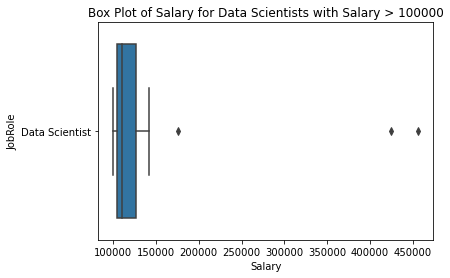

In [43]:
filtered_df = df_emp[(df_emp['Salary'] > 100000) & (df_emp['JobRole'] == 'Data Scientist')]

sb.boxplot(x='Salary', y='JobRole', data=filtered_df)
plt.title('Box Plot of Salary for Data Scientists with Salary > 100000')
plt.show()

In [44]:
filtered_df = df_emp[(df_emp["JobRole"] == "Data Scientist") & (df_emp["Salary"] > 100000)]

count_salary = filtered_df["Salary"].count()

filtered_df['Salary'].sort_values(ascending=False)
count_salary 

26

In [45]:
filtered_df = df_emp[(df_emp["JobRole"] == "Data Scientist") & ((df_emp["Salary"]  == 455643  )| (df_emp["Salary"] == 423941  ))]
filtered_df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
1226,AFC3-E23F,Julissa,Fosbraey,Female,35,Some Travel,Technology,4,CA,White,...,Single,423941,0,No,2021-05-14,No,1,1,1,1
1425,372C-E204,Doralia,Vassie,Female,35,Some Travel,Technology,44,NY,White,...,Single,455643,1,Yes,2022-09-21,No,0,0,0,0


In [46]:

filtered_df = df_emp[(df_emp["JobRole"] == "Data Scientist") & ((df_emp["Salary"] >= 120000) & (df_emp["Salary"] < 423941)) ]
filtered_df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
40,5C61-8F3A,Dyana,Gallie,Female,34,Some Travel,Technology,5,CA,White,...,Single,127432,0,Yes,2012-02-06,No,10,8,9,9
96,2962-039F,Darice,Excell,Female,47,Some Travel,Technology,5,NY,Mixed or multiple ethnic groups,...,Single,133616,0,Yes,2012-04-06,No,10,9,9,0
229,819A-2C9C,Hillary,Atchly,Male,30,No Travel,Technology,7,NY,American Indian or Alaska Native,...,Married,138989,1,Yes,2013-08-14,No,9,2,4,8
230,9811-F345,Wells,Mulholland,Male,42,Some Travel,Technology,40,CA,Black or African American,...,Divorced,142075,1,No,2013-08-15,No,9,9,9,4
299,CACA-0D62,Zarla,Farrans,Female,32,Some Travel,Technology,33,CA,Mixed or multiple ethnic groups,...,Married,121881,2,No,2014-02-09,No,8,7,8,8
1044,66D5-3142,Rivi,Salkild,Female,30,Freq Traveller,Technology,7,NY,White,...,Married,175692,1,No,2019-12-16,No,3,0,3,3
1423,E442-5985,Bear,Bertolin,Male,32,No Travel,Technology,5,CA,White,...,Married,124429,1,No,2022-09-13,No,0,0,0,0


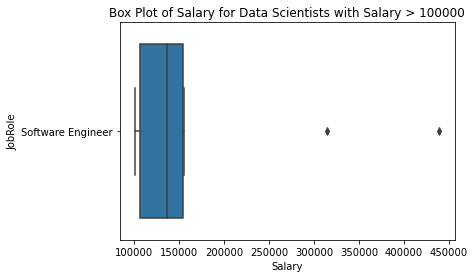

In [47]:
filtered_df = df_emp[(df_emp['Salary'] > 100000) & (df_emp['JobRole'] == 'Software Engineer')]

sb.boxplot(x='Salary', y='JobRole', data=filtered_df)
plt.title('Box Plot of Salary for Data Scientists with Salary > 100000')
plt.show()

In [48]:
filtered_df = df_emp[(df_emp["JobRole"] == "Software Engineer") & (df_emp["Salary"] > 100000)]

count_salary = filtered_df["Salary"].count()

filtered_df['Salary'].sort_values(ascending=False)
#count_salary 

1194    439641
1422    314181
225     155786
394     155259
110     153909
175     152314
1330    144071
69      137427
18      136521
278     130665
549     113448
220     111294
37      105984
400     105126
1453    103429
177     103198
156     100717
Name: Salary, dtype: int64

In [49]:
filtered_df = df_emp[(df_emp["JobRole"] == "Software Engineer") & ((df_emp["Salary"]  == 439641  )| (df_emp["Salary"] == 314181  ))]
filtered_df


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
1194,801E-9D0E,Shaw,McCaw,Male,32,Some Travel,Technology,34,CA,White,...,Single,439641,0,No,2021-02-20,No,1,0,1,1
1422,5E73-CE19,Gus,Dyos,Female,29,Some Travel,Technology,3,CA,White,...,Single,314181,1,Yes,2022-09-13,No,0,0,0,0


In [50]:

filtered_df = df_emp[(df_emp["JobRole"] == "Software Engineer") & ((df_emp["Salary"] >= 150000) & (df_emp["Salary"] < 314181)) ]
filtered_df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
110,3994-472A,Rolf,Cunah,Male,29,Some Travel,Technology,33,CA,White,...,Divorced,153909,1,No,2012-04-23,No,10,10,10,2
175,DF11-9C46,Dulci,Sheryn,Female,32,Some Travel,Technology,2,CA,Mixed or multiple ethnic groups,...,Single,152314,0,Yes,2013-03-30,No,9,4,6,0
225,CD4D-7BBA,Cristian,Massy,Male,43,Some Travel,Technology,38,CA,White,...,Married,155786,1,Yes,2013-07-29,No,9,0,7,5
394,DEB9-1BBF,Edna,Petrello,Female,30,Some Travel,Technology,32,NY,Asian or Asian American,...,Single,155259,0,No,2014-11-10,No,8,3,5,6


In [51]:
df_emp['DistanceFromHome (KM)'].mean()

22.502721088435376

In [52]:
df_emp['DistanceFromHome (KM)'].median()

22.0

In [53]:
df_emp['DistanceFromHome (KM)'].mode()

0    4
Name: DistanceFromHome (KM), dtype: int64

In [54]:

q1 =df_emp['DistanceFromHome (KM)'].quantile(0.25)
q3 =df_emp['DistanceFromHome (KM)'].quantile(0.75)
iqr = q3 - q1
lb =q1 - 1.5*iqr
ub = q3 + 1.5*iqr

print(lb,ub)
out=df_emp[(df_emp['DistanceFromHome (KM)']<lb)|(df_emp['DistanceFromHome (KM)']>ub)]
out


-19.5 64.5


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [55]:
q1 =df_emp['YearsAtCompany'].quantile(0.25)
q3 =df_emp['YearsAtCompany'].quantile(0.75)
iqr = q3 - q1
lb =q1 - 1.5*iqr
ub = q3 + 1.5*iqr

print(lb,ub)
out=df_emp[(df_emp['YearsAtCompany']<lb)|(df_emp['YearsAtCompany']>ub)]
out

-5.5 14.5


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [56]:
df_emp.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education Level', 'EducationField', 'JobRole',
       'MaritalStatus', 'Salary', 'StockOptionLevel', 'OverTime', 'HireDate',
       'Attrition', 'YearsAtCompany', 'YearsInMostRecentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

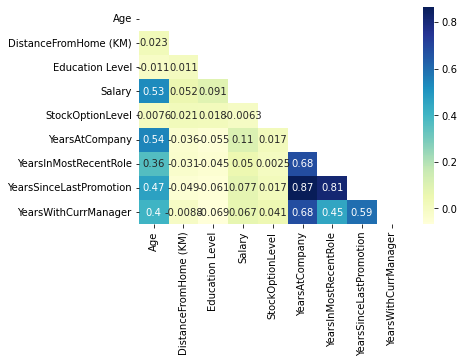

In [57]:
mask = np.triu(np.ones_like(df_emp.corr())) 
dataplot = sb.heatmap(df_emp.corr(), cmap="YlGnBu", annot=True,mask=mask)
plt.show()

In [58]:
# Performance Table Cleaning And Preprocessing
df_pr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   PerformanceID                    6709 non-null   object
 1   EmployeeID                       6709 non-null   object
 2   ReviewDate                       6709 non-null   object
 3   EnvironmentSatisfaction          6709 non-null   int64 
 4   JobSatisfaction                  6709 non-null   int64 
 5   RelationshipSatisfaction         6709 non-null   int64 
 6   TrainingOpportunitiesWithinYear  6709 non-null   int64 
 7   TrainingOpportunitiesTaken       6709 non-null   int64 
 8   WorkLifeBalance                  6709 non-null   int64 
 9   SelfRating                       6709 non-null   int64 
 10  ManagerRating                    6709 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 576.7+ KB


In [59]:
df_pr.shape

(6709, 11)

In [60]:
df_pr.head(10)

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3
5,PR06,F93E-BDEF,1/4/2013,3,3,2,2,0,4,4,4
6,PR07,9E7A-1F70,1/8/2013,3,4,5,2,1,5,4,3
7,PR08,05ED-92F1,1/10/2013,4,5,4,1,1,3,3,2
8,PR09,F72D-261D,1/10/2013,4,5,2,1,1,4,5,4
9,PR10,774E-685D,1/11/2013,5,4,3,2,3,4,5,4


In [61]:
df_pr.describe().T

,count,mean,std,min,25%,50%,75%,max
EnvironmentSatisfaction,6709.0,3.872559,0.940701,1.0,3.0,4.0,5.0,5.0
JobSatisfaction,6709.0,3.430616,1.152565,1.0,2.0,3.0,4.0,5.0
RelationshipSatisfaction,6709.0,3.427336,1.156753,1.0,2.0,3.0,4.0,5.0
TrainingOpportunitiesWithinYear,6709.0,2.012968,0.820310,1.0,1.0,2.0,3.0,3.0
TrainingOpportunitiesTaken,6709.0,1.017290,0.950316,0.0,0.0,1.0,2.0,3.0
WorkLifeBalance,6709.0,3.414667,1.143961,1.0,2.0,3.0,4.0,5.0
SelfRating,6709.0,3.984051,0.816432,3.0,3.0,4.0,5.0,5.0
ManagerRating,6709.0,3.473394,0.961738,2.0,3.0,3.0,4.0,5.0


In [62]:
df_pr.isnull().sum()

PerformanceID                      0
EmployeeID                         0
ReviewDate                         0
EnvironmentSatisfaction            0
JobSatisfaction                    0
RelationshipSatisfaction           0
TrainingOpportunitiesWithinYear    0
TrainingOpportunitiesTaken         0
WorkLifeBalance                    0
SelfRating                         0
ManagerRating                      0
dtype: int64

In [63]:
df_pr.duplicated().sum()



0

In [64]:
df_pr.dtypes

PerformanceID                      object
EmployeeID                         object
ReviewDate                         object
EnvironmentSatisfaction             int64
JobSatisfaction                     int64
RelationshipSatisfaction            int64
TrainingOpportunitiesWithinYear     int64
TrainingOpportunitiesTaken          int64
WorkLifeBalance                     int64
SelfRating                          int64
ManagerRating                       int64
dtype: object

In [65]:
df_pr['ReviewDate'] = pd.to_datetime(df_pr['ReviewDate'])
df_pr


,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3


In [66]:
df_pr.dtypes

PerformanceID                              object
EmployeeID                                 object
ReviewDate                         datetime64[ns]
EnvironmentSatisfaction                     int64
JobSatisfaction                             int64
RelationshipSatisfaction                    int64
TrainingOpportunitiesWithinYear             int64
TrainingOpportunitiesTaken                  int64
WorkLifeBalance                             int64
SelfRating                                  int64
ManagerRating                               int64
dtype: object

In [67]:
df_pr['TrainingOpportunitiesTaken'].unique()

array([0, 3, 2, 1], dtype=int64)

In [68]:
df_pr['Total Employee rating']=df_pr['SelfRating']+df_pr['ManagerRating']

scaler = MinMaxScaler(feature_range=(1, 5))

df_pr['Scaled_Total_Employee_Rating'] = scaler.fit_transform(df_pr[['Total Employee rating']]).round().astype(int)

df_pr

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Total Employee rating,Scaled_Total_Employee_Rating
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4,8,3
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,7,3
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4,9,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2,5,1
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4,9,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4,8,3
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2,5,1
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3,6,2


In [69]:
df_pr= df_pr.drop(columns=['Total Employee rating'])
df_pr

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Scaled_Total_Employee_Rating
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4,3
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,3
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2,1
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4,3
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2,1
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3,2


In [70]:
df_pr['Total Employee Satisfaction'] = df_pr['EnvironmentSatisfaction']+df_pr['JobSatisfaction']+df_pr['RelationshipSatisfaction']+df_pr['WorkLifeBalance']

df_pr['Scaled_Total_Employee_Satisfaction'] = scaler.fit_transform(df_pr[['Total Employee Satisfaction']]).round().astype(int)

df_pr


,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Total Employee Satisfaction,Scaled_Total_Employee_Satisfaction
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4,3,18,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,3,17,4
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4,4,15,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2,1,12,3
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3,3,14,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4,4,16,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4,3,15,4
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2,1,11,3
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3,2,16,4


In [71]:
df_pr = df_pr.drop(columns=['Total Employee Satisfaction'])
df_pr

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4,3,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,3,4
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4,4,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2,1,3
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4,4,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4,3,4
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2,1,3
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3,2,4


In [72]:
training_issues = df_pr[df_pr["TrainingOpportunitiesTaken"] > df_pr["TrainingOpportunitiesWithinYear"]]
print( len(training_issues))
training_issues

823


,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,3,4
9,PR10,774E-685D,2013-01-11,5,4,3,2,3,4,5,4,4,4
15,PR1004,DEC5-9319,2016-03-18,3,4,3,2,3,2,4,4,3,3
23,PR1011,5160-53BD,2016-03-24,4,2,5,1,2,2,5,5,5,3
30,PR1018,C525-8BB9,2016-03-27,3,4,4,1,2,3,4,3,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6668,PR962,17AD-99F5,2016-03-01,3,4,4,1,2,5,4,3,3,4
6678,PR971,0322-D46B,2016-03-03,5,5,2,1,3,2,4,3,3,4
6680,PR973,1054-9C3B,2016-03-05,4,2,5,2,3,4,5,5,5,4
6693,PR985,40A9-8EB0,2016-03-09,4,4,3,1,3,2,3,3,2,3


In [73]:
# (r'\s+', ' ', regex=True)----> replace any number of countinouce spaces with only one
# .str.strip() ----> removes spacse from beganing and end
string_col = df_pr.select_dtypes(include="object").apply(lambda x: x.str.replace(r'\s+', ' ', regex=True).str.strip())
string_col

,PerformanceID,EmployeeID
0,PR01,79F7-78EC
1,PR02,B61E-0F26
2,PR03,F5E3-48BB
3,PR04,0678-748A
4,PR05,541F-3E19
...,...,...
6704,PR995,4F28-CFAF
6705,PR996,7C80-94E0
6706,PR997,8233-2483
6707,PR998,8A5B-3D6E


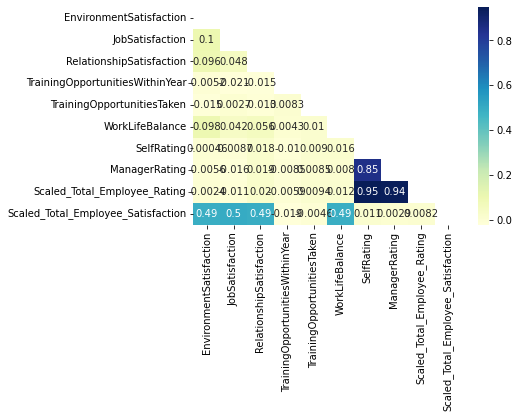

In [74]:
mask = np.triu(np.ones_like(df_pr.corr())) 
dataplot = sb.heatmap(df_pr.corr(), cmap="YlGnBu", annot=True,mask=mask)
plt.show()

In [75]:
# Performance Table Cleaning And Preprocessing
df_st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SatisfactionID     5 non-null      int64 
 1   SatisfactionLevel  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [76]:
df_st.shape

(5, 2)

In [77]:
# This will show the first 5 rows of the cleaned table
df_st.head()

,SatisfactionID,SatisfactionLevel
0,1,Very Dissatisfied
1,2,Dissatisfied
2,3,Neutral
3,4,Satisfied
4,5,Very Satisfied


In [78]:
df_st.describe().T

,count,mean,std,min,25%,50%,75%,max
SatisfactionID,5.0,3.0,1.581139,1.0,2.0,3.0,4.0,5.0


In [79]:
df_st.duplicated().sum()

0

In [80]:
df_st.isnull().sum()

SatisfactionID       0
SatisfactionLevel    0
dtype: int64

In [81]:
df_st.dtypes

SatisfactionID        int64
SatisfactionLevel    object
dtype: object

In [82]:
# - Remove leading and trailing spaces from all columns
df_st = df_st.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [83]:
# Rating Table Cleaning And Preprocessing

df_rt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RatingID     5 non-null      int64 
 1   RatingLevel  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [84]:
df_rt.shape

(5, 2)

In [85]:
df_rt.dtypes

RatingID        int64
RatingLevel    object
dtype: object

In [86]:
df_rt.describe().T

,count,mean,std,min,25%,50%,75%,max
RatingID,5.0,3.0,1.581139,1.0,2.0,3.0,4.0,5.0


In [87]:
df_rt.head()

,RatingID,RatingLevel
0,1,Unacceptable
1,2,Needs Improvement
2,3,Meets Expectation
3,4,Exceeds Expectation
4,5,Above and Beyond


In [88]:
df_rt.duplicated().sum()

0

In [89]:
df_rt.isnull().sum()

RatingID       0
RatingLevel    0
dtype: int64

In [90]:
# - Remove leading and trailing spaces from all columns
df_rt = df_rt.applymap(lambda x: x.strip() if isinstance(x, str) else x)

In [91]:
# Correcting Wrong Values

df_edu.at[2, "EducationLevel"] = "Bachelor’s"
df_edu.at[3, "EducationLevel"] = "Master’s"
df_edu.at[4, "EducationLevel"] = "Doctorate Degree"


df_edu

,EducationLevelID,EducationLevel
0,1,No Formal Qualifications
1,2,High School
2,3,Bachelor’s
3,4,Master’s
4,5,Doctorate Degree


In [92]:
df_edu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EducationLevelID  5 non-null      int64 
 1   EducationLevel    5 non-null      object
dtypes: int64(1), object(1)
memory usage: 208.0+ bytes


In [93]:
df_edu.describe().T

,count,mean,std,min,25%,50%,75%,max
EducationLevelID,5.0,3.0,1.581139,1.0,2.0,3.0,4.0,5.0


In [94]:
df_edu.head()

,EducationLevelID,EducationLevel
0,1,No Formal Qualifications
1,2,High School
2,3,Bachelor’s
3,4,Master’s
4,5,Doctorate Degree


In [95]:
df_edu.duplicated().sum()

0

In [96]:
df_edu.isnull().sum()

EducationLevelID    0
EducationLevel      0
dtype: int64

In [97]:
df_edu.shape

(5, 2)

In [98]:
df_edu.dtypes

EducationLevelID     int64
EducationLevel      object
dtype: object

In [99]:
# - Remove leading and trailing spaces from all columns
df_edu = df_edu.applymap(lambda x: x.strip() if isinstance(x, str) else x)

In [105]:
df_emp.to_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\Employee.csv",index=False,encoding='utf-8-sig')
print("done")

done


In [106]:
df_pr.to_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\PerformanceRating.csv",index=False,encoding='utf-8-sig')
df_st.to_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\SatisfiedLevel.csv",index=False,encoding='utf-8-sig')
df_rt.to_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\RatingLevel.csv",index=False,encoding='utf-8-sig')
df_edu.to_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\EducationLevel.csv",index=False,encoding='utf-8-sig')

print("done")


done


In [107]:
df =pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\Employee.csv")
df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,HR,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,HR,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,Single,38508,0,No,2022-12-26,No,0,0,0,0
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,Single,92995,3,No,2022-12-30,No,0,0,0,0
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,Single,63375,0,No,2022-12-30,No,0,0,0,0
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,Married,46521,0,No,2022-12-30,No,0,0,0,0


In [108]:
d=pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HR\PerformanceRating.csv")
d

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4,3,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3,3,4
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4,4,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2,1,3
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,2016-03-14,5,3,3,3,1,5,5,4,4,4
6705,PR996,7C80-94E0,2016-03-14,3,5,4,2,1,3,4,4,3,4
6706,PR997,8233-2483,2016-03-14,3,4,2,3,1,2,3,2,1,3
6707,PR998,8A5B-3D6E,2016-03-15,5,2,5,2,2,4,3,3,2,4


In [104]:
df_emp.shape

(1470, 23)

In [110]:
df_emp_perf = pd.merge(df_emp, df_pr, how='left', on='EmployeeID')

df_emp_perf_edu=pd.merge(df_emp_perf , df_edu, left_on='Education Level', right_on='EducationLevelID', how='left')

df_emp_perf__edu_rating = pd.merge(df_emp_perf_edu , df_rt, left_on='ManagerRating', right_on='RatingID', how='left')

df= pd.merge(df_emp_perf__edu_rating, df_st, left_on='JobSatisfaction', right_on='SatisfactionID', how='left')

df


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction,EducationLevelID,EducationLevel,RatingID,RatingLevel,SatisfactionID,SatisfactionLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3.0,3.0,2.0,3.0,5,Doctorate Degree,3.0,Meets Expectation,3.0,Neutral
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3.0,2.0,1.0,4.0,5,Doctorate Degree,2.0,Needs Improvement,4.0,Satisfied
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,5.0,5.0,5.0,4.0,5,Doctorate Degree,5.0,Above and Beyond,5.0,Very Satisfied
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,5.0,4.0,4.0,2.0,5,Doctorate Degree,4.0,Exceeds Expectation,3.0,Neutral
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,4.0,3.0,3.0,3.0,5,Doctorate Degree,3.0,Meets Expectation,4.0,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,NaN,NaN,NaN,NaN,2,High School,NaN,NaN,NaN,NaN
6895,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,NaN,NaN,NaN,NaN,3,Bachelor’s,NaN,NaN,NaN,NaN
6896,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,NaN,NaN,NaN,NaN,4,Master’s,NaN,NaN,NaN,NaN
6897,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,NaN,NaN,NaN,NaN,3,Bachelor’s,NaN,NaN,NaN,NaN


In [111]:
df_unique = df.drop_duplicates(subset='EmployeeID')
df_unique

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,SelfRating,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction,EducationLevelID,EducationLevel,RatingID,RatingLevel,SatisfactionID,SatisfactionLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3.0,3.0,2.0,3.0,5,Doctorate Degree,3.0,Meets Expectation,3.0,Neutral
9,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,4.0,4.0,3.0,3.0,4,Master’s,4.0,Exceeds Expectation,3.0,Neutral
18,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,HR,29,CA,Asian or Asian American,...,3.0,2.0,1.0,2.0,4,Master’s,2.0,Needs Improvement,3.0,Neutral
27,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,3.0,3.0,2.0,3.0,3,Bachelor’s,3.0,Meets Expectation,5.0,Very Satisfied
36,42CC-040A,Stace,Savege,Female,29,Some Travel,HR,29,CA,White,...,3.0,2.0,1.0,4.0,2,High School,2.0,Needs Improvement,3.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6894,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,NaN,NaN,NaN,NaN,2,High School,NaN,NaN,NaN,NaN
6895,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,NaN,NaN,NaN,NaN,3,Bachelor’s,NaN,NaN,NaN,NaN
6896,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,NaN,NaN,NaN,NaN,4,Master’s,NaN,NaN,NaN,NaN
6897,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,NaN,NaN,NaN,NaN,3,Bachelor’s,NaN,NaN,NaN,NaN


In [112]:
# Save As Csv File

df.to_csv("HRData_Final.csv", index=False)
print('Done')

Done


In [113]:
df_unique.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education Level', 'EducationField', 'JobRole',
       'MaritalStatus', 'Salary', 'StockOptionLevel', 'OverTime', 'HireDate',
       'Attrition', 'YearsAtCompany', 'YearsInMostRecentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PerformanceID',
       'ReviewDate', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating', 'Scaled_Total_Employee_Rating',
       'Scaled_Total_Employee_Satisfaction', 'EducationLevelID',
       'EducationLevel', 'RatingID', 'RatingLevel', 'SatisfactionID',
       'SatisfactionLevel'],
      dtype='object')